In [1]:
!apt-get -qq install tesseract-ocr
!pip -q install pytesseract pillow groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 8.8 MB/s eta 0:00:00


In [2]:
from google.colab import userdata

try:
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")

    if not GROQ_API_KEY:
        raise ValueError("GROQ_API_KEY not found.")

    print("✅ API Key Loaded Successfully.")

except Exception as e:
    print("❌", e)

✅ API Key Loaded Successfully.


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Restaurent_image.jpg to Restaurent_image.jpg


In [6]:
import base64

filename = list(uploaded.keys())[0]

with open(filename, "rb") as f:
    encoded = base64.b64encode(f.read()).decode()

print("Base64 Length:", len(encoded))
print(encoded[:300] + "...")

Base64 Length: 112768
/9j/4AAQSkZJRgABAQEAYABgAAD//gA7Q1JFQVRPUjogZ2QtanBlZyB2MS4wICh1c2luZyBJSkcgSlBFRyB2ODApLCBxdWFsaXR5ID0gOTAK/9sAQwADAgIDAgIDAwMDBAMDBAUIBQUEBAUKBwcGCAwKDAwLCgsLDQ4SEA0OEQ4LCxAWEBETFBUVFQwPFxgWFBgSFBUU/9sAQwEDBAQFBAUJBQUJFA0LDRQUFBQUFBQUFBQUFBQUFBQUFBQUFBQUFBQUFBQUFBQUFBQUFBQUFBQUFBQUFBQUFBQU/8AAEQgF...


Receipt Preview:


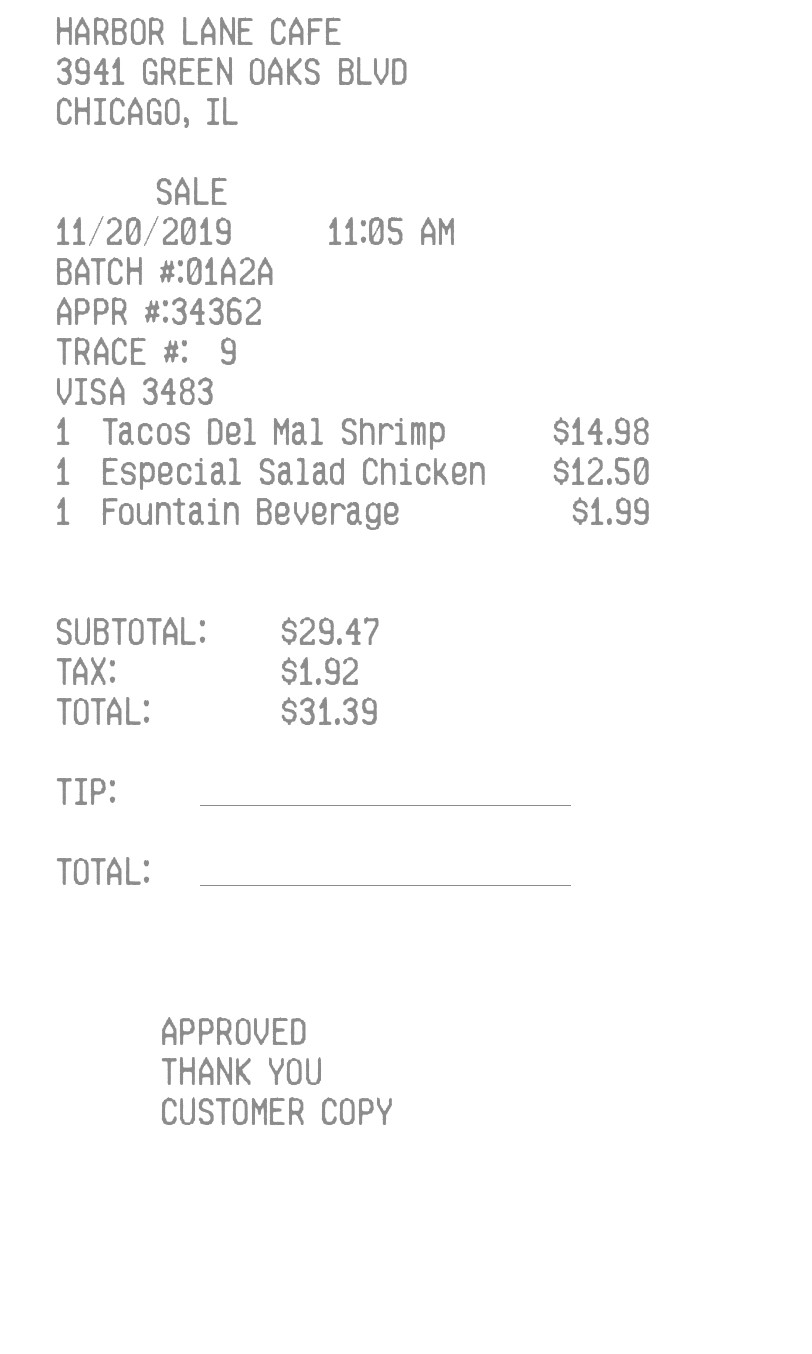


Extracted Text:

HARBOR LANE CAFE
3941 GREEN OAKS BLVD
CHICAGO, IL

SALE
11/20/2019 11:05 AM
BATCH #:01A2A
APPR #:34362

TRACE # 9

VISA 3483

1 Tacos Del Mal Shrimp $14.98
1 Especial Salad Chicken $12.50
1 Fountain Beverage $1.99

SUBTOTAL: $29.47
TAX: $1.92
TOTAL: $31.39

TIP:
TOTAL:

APPROVED
THANK YOU
CUSTOMER COPY



In [7]:
from PIL import Image
import pytesseract

filename = list(uploaded.keys())[0]

image = Image.open(filename)

print("Receipt Preview:")
display(image)

text = pytesseract.image_to_string(image)

print("\nExtracted Text:\n")
print(text)

In [8]:
from groq import Groq
import json

client = Groq(api_key=GROQ_API_KEY)

prompt = f"""
You are an expert receipt parser.

Extract the following fields.

Restaurant Name
Date
Items Ordered
Subtotal
Tax
Total

Return ONLY valid JSON.

Receipt Text:

{text}
"""

response = client.chat.completions.create(

    model="llama-3.1-8b-instant",

    temperature=0,

    messages=[
        {
            "role":"user",
            "content":prompt
        }
    ]
)

result = response.choices[0].message.content

print(result)

```json
{
  "Restaurant Name": "HARBOR LANE CAFE",
  "Date": "11/20/2019 11:05 AM",
  "Items Ordered": [
    {"Item": "Tacos Del Mal Shrimp", "Price": 14.98},
    {"Item": "Especial Salad Chicken", "Price": 12.50},
    {"Item": "Fountain Beverage", "Price": 1.99}
  ],
  "Subtotal": 29.47,
  "Tax": 1.92,
  "Total": 31.39
}
```

Note: The "Items Ordered" field is an array of objects, where each object represents an item with its name and price.


In [9]:
import json

try:

    data = json.loads(result)

    subtotal = float(data["subtotal"])
    tax = float(data["tax"])
    total = float(data["total"])

    print("\nValidation")

    if abs((subtotal + tax) - total) < 0.05:
        print("✅ Total is correct")

    else:
        print("❌ Total does NOT match")

except Exception as e:

    print("Validation Error:", e)

Validation Error: Expecting value: line 1 column 1 (char 0)


In [10]:
print("="*70)
print("ANALYSIS")
print("="*70)

print("""
1. Uploaded a receipt image.

2. OCR extracted text using Tesseract.

3. Groq parsed the text into structured JSON.

4. The subtotal, tax and total were validated.

5. The receipt information became machine-readable.
""")

ANALYSIS

1. Uploaded a receipt image.

2. OCR extracted text using Tesseract.

3. Groq parsed the text into structured JSON.

4. The subtotal, tax and total were validated.

5. The receipt information became machine-readable.

